In [ ]:
!pip install -q ultralytics

In [4]:
import os
import cv2
import glob
import shutil
import random
import yaml
import json
import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

BASE_INPUT_DIR = '/kaggle/input/datasets/orvile/bccd-blood-cell-count-and-detection-dataset'

DIRS = {
    'train': {'img': os.path.join(BASE_INPUT_DIR, 'train', 'img'), 'ann': os.path.join(BASE_INPUT_DIR, 'train', 'ann')},
    'val':   {'img': os.path.join(BASE_INPUT_DIR, 'val', 'img'),   'ann': os.path.join(BASE_INPUT_DIR, 'val', 'ann')},
    'test':  {'img': os.path.join(BASE_INPUT_DIR, 'test', 'img'),  'ann': os.path.join(BASE_INPUT_DIR, 'test', 'ann')},
}

WORK_DIR = '/kaggle/working/bccd_yolo'

print("Checking dataset paths...")
for split in ['train', 'val', 'test']:
    n_imgs = len(glob.glob(os.path.join(DIRS[split]['img'], '*.*')))
    n_anns = len(glob.glob(os.path.join(DIRS[split]['ann'], '*.json')))
    print(f"   - {split.upper()}: {n_imgs} images, {n_anns} json files")


Checking dataset paths...
   - TRAIN: 205 images, 205 json files
   - VAL: 87 images, 87 json files
   - TEST: 72 images, 72 json files


## Helper functions
Loading images/annotations and drawing results.

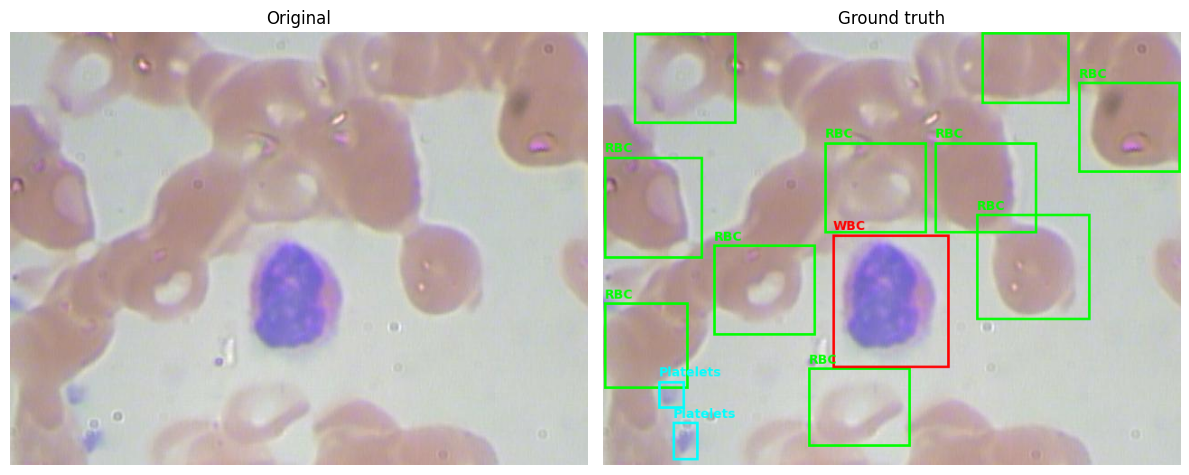

In [5]:
def get_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Image not found")
    return image

def get_annotations_path(image_path):
    base_dir = os.path.dirname(os.path.dirname(image_path))  # Go up to split folder
    filename = os.path.basename(image_path)
    annotation_path = os.path.join(base_dir, 'ann', filename + ".json")
    if not os.path.exists(annotation_path):
        raise FileNotFoundError(f"Annotation file not found at: {annotation_path}")
    return annotation_path

def get_annotations(annotations_path):
    with open(annotations_path, 'r', encoding='utf-8') as f:
        return json.load(f)

def get_annotated_image(image, annotations):
    """Burns ground-truth bounding boxes into a copy of the image."""
    fig, ax = plt.subplots(figsize=(image.shape[1] / 100, image.shape[0] / 100), dpi=100)
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.axis('off')
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

    colors = {'WBC': 'red', 'RBC': 'lime', 'Platelets': 'cyan'}
    for obj in annotations.get('objects', []):
        if obj['geometryType'] == 'rectangle':
            p1, p2 = obj['points']['exterior']
            x, y, w, h = p1[0], p1[1], p2[0] - p1[0], p2[1] - p1[1]
            label = obj['classTitle']
            color = colors.get(label, 'yellow')
            ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, fill=False))
            ax.text(x, y - 5, label, color=color, fontsize=10, fontweight='bold')

    io_buf = io.BytesIO()
    fig.savefig(io_buf, format='raw', dpi=100)
    io_buf.seek(0)
    img_arr = np.frombuffer(io_buf.getvalue(), dtype=np.uint8)
    img_arr = img_arr.reshape(int(fig.bbox.bounds[3]), int(fig.bbox.bounds[2]), -1)[:, :, :3]
    plt.close(fig)
    return cv2.cvtColor(img_arr, cv2.COLOR_RGB2BGR)

def plot_data(data, titles=None):
    if not isinstance(data, list):
        data = [data]
    if titles is None or len(titles) != len(data):
        titles = [None] * len(data)

    fig, axes = plt.subplots(1, len(data), figsize=(6 * len(data), 5))
    if len(data) == 1:
        axes = [axes]

    for ax, item, title in zip(axes, data, titles):
        if item.ndim == 3:
            ax.imshow(cv2.cvtColor(item, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(item, cmap='gray')
        ax.axis('off')
        ax.set_title(title or "Image")

    plt.tight_layout()
    plt.show()

sample_image_path = glob.glob(os.path.join(DIRS['test']['img'], '*.jpeg'))[0]
sample_image = get_image(sample_image_path)
sample_annotations = get_annotations(get_annotations_path(sample_image_path))
sample_annotated_image = get_annotated_image(sample_image, sample_annotations)
plot_data([sample_image, sample_annotated_image], titles=["Original", "Ground truth"])


## Classical image processing pipeline

- **WBCs**: CLAHE contrast enhancement, then HSV color masking (WBCs are distinctly purple) + morphology + size filtering.
- **Platelets**: same HSV mask as WBCs, with the WBC regions removed, then filtered by size/circularity.
- **RBCs**: CLAHE on the Green channel, adaptive thresholding, then the Watershed algorithm to split overlapping/clustered cells.


In [6]:
def apply_CLAHE(image):
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l_clahe = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l_clahe, a, b)), cv2.COLOR_LAB2BGR)

def apply_gaussian_blur(image, kernel_size=(7, 7)):
    return cv2.GaussianBlur(image, kernel_size, 0)

def get_hsv_mask(hsv_image, lower_thresh, upper_thresh):
    return cv2.inRange(hsv_image, lower_thresh, upper_thresh)

def clean_wbc_morphology(mask):
    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_open = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open, iterations=2)
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20, 20))
    return cv2.morphologyEx(mask_open, cv2.MORPH_CLOSE, kernel_close, iterations=2)

def filter_wbc_by_size(mask, min_area=1500):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    final_mask = np.zeros_like(mask)
    count = 0
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] > min_area:
            final_mask[labels == i] = 255
            count += 1
    return final_mask, count

def get_wbc_mask(hsv_image, lower_thresh, upper_thresh):
    raw_mask = get_hsv_mask(hsv_image, lower_thresh, upper_thresh)
    morph_mask = clean_wbc_morphology(raw_mask)
    return filter_wbc_by_size(morph_mask, min_area=1500)


In [7]:
def platelets_remove_wbc_mask(candidate_mask, wbc_mask):
    kernel = np.ones((9, 9), np.uint8)
    wbc_dilated = cv2.dilate(wbc_mask, kernel, iterations=10)
    wbc_inverted = cv2.bitwise_not(wbc_dilated)
    return cv2.bitwise_and(candidate_mask, candidate_mask, mask=wbc_inverted)

def filter_platelets_by_shape(mask, min_area=50, max_area=3000, min_circularity=0.75):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    cleaned_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    cnts, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    final_mask = np.zeros_like(cleaned_mask)
    count = 0
    for c in cnts:
        area = cv2.contourArea(c)
        if min_area < area < max_area:
            perimeter = cv2.arcLength(c, True)
            if perimeter == 0:
                continue
            circularity = (4 * np.pi * area) / (perimeter ** 2)
            if circularity > min_circularity:
                cv2.drawContours(final_mask, [c], -1, 255, -1)
                count += 1
    return final_mask, count

def get_platelet_mask(hsv_image, wbc_mask, lower_thresh, upper_thresh):
    color_candidates = get_hsv_mask(hsv_image, lower_thresh, upper_thresh)
    wbc_free_candidates = platelets_remove_wbc_mask(color_candidates, wbc_mask)
    return filter_platelets_by_shape(wbc_free_candidates)


In [8]:
def rbc_extract_and_clahe(image):
    g = image[:, :, 1]
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    return clahe.apply(g)

def rbc_apply_thresholding(g_blurred):
    return cv2.adaptiveThreshold(
        g_blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, blockSize=201, C=2
    )

def rbc_remove_wbc_mask(wbc_mask, thresh):
    wbc_dilated = cv2.dilate(wbc_mask, np.ones((5, 5), np.uint8), iterations=2)
    thresh[wbc_dilated > 0] = 0
    return thresh

def rbc_get_sure_bg(thresh):
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=3)
    sure_bg = cv2.dilate(closing, kernel, iterations=3)
    return sure_bg, closing

def rbc_get_sure_foreground(closing, sure_bg):
    dist_transform = cv2.distanceTransform(closing, cv2.DIST_L2, 5)
    dist_transform = cv2.GaussianBlur(dist_transform, (3, 3), 0)
    _, sure_fg = cv2.threshold(dist_transform, 0.35 * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)
    return sure_fg, unknown

def rbc_apply_watershed(sure_fg, unknown, image):
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0
    return cv2.watershed(image, markers)

def rbc_size_filtering(typical_rbc_area, markers):
    min_thresh = typical_rbc_area * 0.4
    clump_thresh = typical_rbc_area * 1.8
    final_count = 0
    new_markers = markers.copy()

    for label in np.unique(markers):
        if label <= 1:
            continue
        area = np.sum(markers == label)
        if area < min_thresh:
            new_markers[markers == label] = 1
        elif area > clump_thresh:
            final_count += int(round(area / typical_rbc_area))
        else:
            final_count += 1

    return new_markers, final_count

def get_rbc_watershed(image, wbc_mask, typical_rbc_area=6000):
    g_clahe = rbc_extract_and_clahe(image)
    g_blurred = apply_gaussian_blur(g_clahe, (5, 5))
    thresh = rbc_apply_thresholding(g_blurred)
    thresh = rbc_remove_wbc_mask(wbc_mask, thresh)
    sure_bg, closing = rbc_get_sure_bg(thresh)
    sure_fg, unknown = rbc_get_sure_foreground(closing, sure_bg)
    markers = rbc_apply_watershed(sure_fg, unknown, image)
    return rbc_size_filtering(typical_rbc_area, markers)


WBC=1, RBC=12, Platelets=0


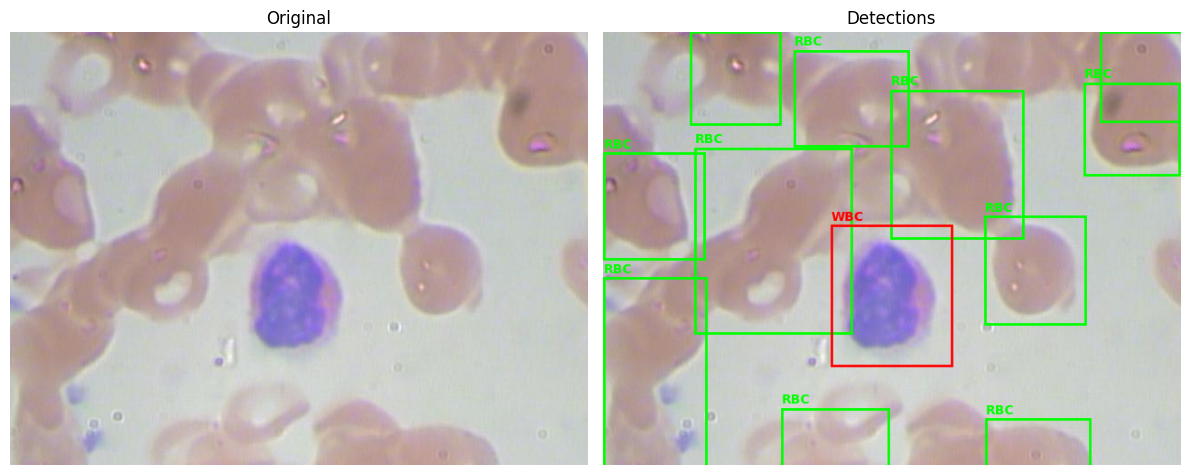

In [9]:
def markers_to_detections(markers, wbc_mask, platelet_mask, padding=10):
    """Converts segmentation markers/masks into padded bounding boxes."""
    detections = []
    h_img, w_img = markers.shape[:2]

    def get_padded_box(x, y, w, h, pad, max_w, max_h):
        new_x, new_y = max(0, x - pad), max(0, y - pad)
        new_w = min(max_w - new_x, w + 2 * pad)
        new_h = min(max_h - new_y, h + 2 * pad)
        return [int(new_x), int(new_y), int(new_w), int(new_h)]

    for label in np.unique(markers):
        if label <= 1:
            continue
        cell_mask = np.zeros(markers.shape, dtype="uint8")
        cell_mask[markers == label] = 255
        cnts, _ = cv2.findContours(cell_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if cnts:
            x, y, w, h = cv2.boundingRect(cnts[0])
            detections.append({'classTitle': 'RBC', 'box': get_padded_box(x, y, w, h, padding, w_img, h_img)})

    cnts_wbc, _ = cv2.findContours(wbc_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for c in cnts_wbc:
        x, y, w, h = cv2.boundingRect(c)
        detections.append({'classTitle': 'WBC', 'box': get_padded_box(x, y, w, h, padding + 10, w_img, h_img)})

    cnts_plat, _ = cv2.findContours(platelet_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for c in cnts_plat:
        x, y, w, h = cv2.boundingRect(c)
        detections.append({'classTitle': 'Platelets', 'box': get_padded_box(x, y, w, h, padding, w_img, h_img)})

    return detections

def visualize_detections(image, detections):
    fig, ax = plt.subplots(figsize=(image.shape[1] / 100, image.shape[0] / 100), dpi=100)
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.axis('off')
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

    colors = {'WBC': 'red', 'RBC': 'lime', 'Platelets': 'cyan'}
    for obj in detections:
        label = obj['classTitle']
        x, y, w, h = obj['box']
        color = colors.get(label, 'yellow')
        ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, fill=False))
        ax.text(x, y - 5, label, color=color, fontsize=10, fontweight='bold')

    io_buf = io.BytesIO()
    fig.savefig(io_buf, format='raw', dpi=100)
    io_buf.seek(0)
    img_arr = np.frombuffer(io_buf.getvalue(), dtype=np.uint8)
    img_arr = img_arr.reshape(int(fig.bbox.bounds[3]), int(fig.bbox.bounds[2]), -1)[:, :, :3]
    plt.close(fig)
    return cv2.cvtColor(img_arr, cv2.COLOR_RGB2BGR)

class ClassicalCellDetector:
    def __init__(self):
        self.lower_purple = np.array([79, 77, 109])
        self.upper_purple = np.array([151, 212, 212])
        self.typical_rbc_area = 6000

    def detect_wbc(self, image):
        hsv = cv2.cvtColor(apply_gaussian_blur(image), cv2.COLOR_BGR2HSV)
        return get_wbc_mask(hsv, self.lower_purple, self.upper_purple)

    def detect_platelets(self, image, wbc_mask):
        hsv = cv2.cvtColor(apply_gaussian_blur(image), cv2.COLOR_BGR2HSV)
        return get_platelet_mask(hsv, wbc_mask, self.lower_purple, self.upper_purple)

    def detect_rbc(self, image, wbc_mask):
        return get_rbc_watershed(image, wbc_mask, typical_rbc_area=self.typical_rbc_area)

    def run_pipeline(self, image, visualize=False):
        clahe_image = apply_CLAHE(image)
        wbc_mask, wbc_count = self.detect_wbc(clahe_image.copy())
        platelet_mask, platelet_count = self.detect_platelets(clahe_image.copy(), wbc_mask)
        rbc_markers, rbc_count = self.detect_rbc(image.copy(), wbc_mask)

        detections = markers_to_detections(rbc_markers, wbc_mask, platelet_mask)
        vis_boxes = visualize_detections(image.copy(), detections)

        if visualize:
            print(f"WBC={wbc_count}, RBC={rbc_count}, Platelets={platelet_count}")
            plot_data([image, vis_boxes], titles=["Original", "Detections"])

        return {
            'wbc_count': wbc_count,
            'rbc_count': rbc_count,
            'platelet_count': platelet_count,
            'detections': detections,
            'final_vis': vis_boxes,
        }

# Quick demo on one test image
detector = ClassicalCellDetector()
result = detector.run_pipeline(sample_image, visualize=True)


## YOLOv8

Fine-tunes a pretrained yolov8n.pt on the BCCD dataset

In [12]:
WORK_DIR = '/kaggle/working/bccd_yolo'
classes = ['WBC', 'RBC', 'Platelets']
class_map = {name: i for i, name in enumerate(classes)}

if os.path.exists(WORK_DIR):
    shutil.rmtree(WORK_DIR)

def process_split(split_name):
    print(f"Processing {split_name}...")
    base_input = f'/kaggle/input/bccd-blood-cell-count-and-detection-dataset/{split_name}'
    src_img_dir, src_ann_dir = os.path.join(base_input, 'img'), os.path.join(base_input, 'ann')
    dst_img_dir = os.path.join(WORK_DIR, 'images', split_name)
    dst_lbl_dir = os.path.join(WORK_DIR, 'labels', split_name)
    os.makedirs(dst_img_dir, exist_ok=True)
    os.makedirs(dst_lbl_dir, exist_ok=True)

    count = 0
    for img_path in glob.glob(os.path.join(src_img_dir, '*.jpeg')):
        filename = os.path.basename(img_path)
        json_path = os.path.join(src_ann_dir, filename + ".json")
        if not os.path.exists(json_path):
            continue

        shutil.copy(img_path, os.path.join(dst_img_dir, filename))
        with open(json_path, 'r') as f:
            data = json.load(f)
        img_h, img_w = data['size']['height'], data['size']['width']

        txt_path = os.path.join(dst_lbl_dir, os.path.splitext(filename)[0] + ".txt")
        with open(txt_path, 'w') as out:
            for obj in data.get('objects', []):
                if obj['classTitle'] not in class_map or obj['geometryType'] != 'rectangle':
                    continue
                (x1, y1), (x2, y2) = obj['points']['exterior']
                cx, cy = (x1 + x2) / 2 / img_w, (y1 + y2) / 2 / img_h
                w, h = abs(x2 - x1) / img_w, abs(y2 - y1) / img_h
                out.write(f"{class_map[obj['classTitle']]} {cx} {cy} {w} {h}\n")
        count += 1
    print(f"   -> {count} images processed")

for split in ['train', 'val', 'test']:
    process_split(split)

data_yaml = {
    'path': WORK_DIR,
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'names': {i: name for name, i in class_map.items()},
}
with open(os.path.join(WORK_DIR, 'data.yaml'), 'w') as f:
    yaml.dump(data_yaml, f)

print("data.yaml written to", os.path.join(WORK_DIR, 'data.yaml'))


Processing train...
   -> 0 images processed
Processing val...
   -> 0 images processed
Processing test...
   -> 0 images processed
data.yaml written to /kaggle/working/bccd_yolo/data.yaml


In [16]:
import os
import json
import shutil
import cv2
from pathlib import Path
from tqdm import tqdm


INPUT_BASE_DIR = glob.glob('/kaggle/input/datasets/orvile/bccd-blood-cell-count-and-detection-dataset')[0]
OUTPUT_BASE_DIR = '/kaggle/working/bccd_yolo'

CLASS_MAPPING = {'WBC': 0, 'RBC': 1, 'Platelets': 2}
SPLITS = ['train', 'val', 'test']

def convert_json_to_yolo(image_path, json_path, output_txt_path):
    """Reads a JSON annotation file, converts coordinates to YOLO format, and writes a .txt file."""
    img = cv2.imread(str(image_path))
    if img is None:
        return False
    
    img_h, img_w = img.shape[:2]
    
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    yolo_lines = []
    for obj in data.get('objects', []):
        if obj['geometryType'] == 'rectangle' and obj['classTitle'] in CLASS_MAPPING:
            class_id = CLASS_MAPPING[obj['classTitle']]
            
            p1, p2 = obj['points']['exterior']
            xmin, ymin = p1[0], p1[1]
            xmax, ymax = p2[0], p2[1]
            
            dw = 1.0 / img_w
            dh = 1.0 / img_h
            
            x_center = (xmin + xmax) / 2.0 * dw
            y_center = (ymin + ymax) / 2.0 * dh
            w = (xmax - xmin) * dw
            h = (ymax - ymin) * dh
            
            x_center = max(0.0, min(1.0, x_center))
            y_center = max(0.0, min(1.0, y_center))
            w = max(0.0, min(1.0, w))
            h = max(0.0, min(1.0, h))
            
            yolo_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")
            
    if yolo_lines:
        with open(output_txt_path, 'w') as f:
            f.write('\n'.join(yolo_lines))
        return True
    return False

print("Starting dataset conversion to YOLO format...")
for split in SPLITS:
    src_img_dir = Path(INPUT_BASE_DIR) / split / 'img'
    src_ann_dir = Path(INPUT_BASE_DIR) / split / 'ann'
    
    dst_img_dir = Path(OUTPUT_BASE_DIR) / 'images' / split
    dst_lbl_dir = Path(OUTPUT_BASE_DIR) / 'labels' / split
    
    # Create target directories
    os.makedirs(dst_img_dir, exist_ok=True)
    os.makedirs(dst_lbl_dir, exist_ok=True)
    
    # Find all images in current split
    image_paths = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
        image_paths.extend(src_img_dir.glob(ext))
        
    print(f"\nProcessing '{split}' split ({len(image_paths)} images found)...")
    
    success_count = 0
    for img_path in tqdm(image_paths):
        json_path = src_ann_dir / f"{img_path.name}.json"
        
        if json_path.exists():
            txt_filename = img_path.stem + '.txt'
            dst_txt_path = dst_lbl_dir / txt_filename
            
            if convert_json_to_yolo(img_path, json_path, dst_txt_path):
                shutil.copy(str(img_path), str(dst_img_dir / img_path.name))
                success_count += 1
                
    print(f"Successfully processed {success_count}/{len(image_paths)} files for '{split}'.")

print("\nDataset ready! You can now run your YOLO training loop safely.")

Starting dataset conversion to YOLO format...

Processing 'train' split (205 images found)...


100%|██████████| 205/205 [00:02<00:00, 70.36it/s]


Successfully processed 205/205 files for 'train'.

Processing 'val' split (87 images found)...


100%|██████████| 87/87 [00:01<00:00, 78.28it/s]


Successfully processed 87/87 files for 'val'.

Processing 'test' split (72 images found)...


100%|██████████| 72/72 [00:00<00:00, 79.41it/s]

Successfully processed 72/72 files for 'test'.

Dataset ready! You can now run your YOLO training loop safely.


In [17]:
TRAIN_NEW_MODEL = True
SAVED_MODEL_PATH = '/kaggle/input/bccd-yolo-weights-v1/best.pt'

if TRAIN_NEW_MODEL:
    print("Starting training...")
    model = YOLO('yolov8n.pt')
    results = model.train(
        data=os.path.join(WORK_DIR, 'data.yaml'),
        epochs=50,
        imgsz=640,
        batch=32,
        project='bccd_project',
        name='yolo_bccd',
        verbose=False,
        exist_ok=True,
    )
    path_to_best_model = str(model.trainer.best)
    print(f"Training completed. Best model saved at: {path_to_best_model}")
else:
    print("Loading existing model...")
    if not os.path.exists(SAVED_MODEL_PATH):
        raise FileNotFoundError(f"{SAVED_MODEL_PATH} not found. Check /kaggle/input for the correct folder name.")
    model = YOLO(SAVED_MODEL_PATH)
    path_to_best_model = SAVED_MODEL_PATH
    print(f"Model loaded from: {SAVED_MODEL_PATH}")

print("\nRunning validation...")
metrics = model.val(data=os.path.join(WORK_DIR, 'data.yaml'))


Starting training...
Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/bccd_yolo/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_bccd, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, o

## Save the weights

In [20]:
EXPORT_PATH = '/kaggle/working/best.pt'
shutil.copy(path_to_best_model, EXPORT_PATH)
print(f"Weights ready for download at: {EXPORT_PATH}")


Weights ready for download at: /kaggle/working/best.pt


### Quick check
Run the exported model on one test image to confirm it works.

YOLO counts: {'WBC': 1, 'RBC': 12, 'Platelets': 3}


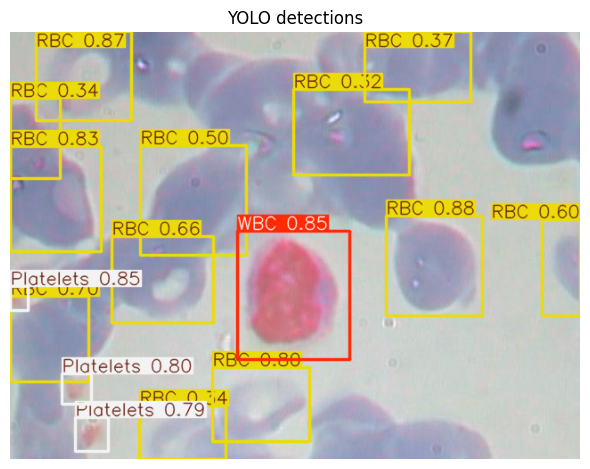

In [19]:
demo_path = glob.glob(os.path.join(DIRS['test']['img'], '*.jpeg'))[0]
yolo_result = model.predict(demo_path, conf=0.25, verbose=False)[0]

counts = {'WBC': 0, 'RBC': 0, 'Platelets': 0}
for box in yolo_result.boxes:
    counts[classes[int(box.cls[0])]] += 1

print("YOLO counts:", counts)
plot_data([cv2.cvtColor(yolo_result.plot(), cv2.COLOR_RGB2BGR)], titles=["YOLO detections"])
